In [1]:
import optuna
import sklearn
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split,cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier,plot_tree
from optuna.samplers import GridSampler,RandomSampler

In [18]:
df = pd.read_csv("one_hand_data1111.csv")

In [19]:
df1 = pd.read_csv("one_hand_data2222.csv")

In [20]:
df2 = pd.read_csv("one_hand_data3333.csv")

In [21]:
df3 = pd.read_csv("one_hand_data4444.csv")

In [22]:
df1.duplicated().sum()

0

In [23]:
df.duplicated().sum()

0

In [24]:
df2.duplicated().sum()

0

In [25]:
df3.duplicated().sum()

0

In [29]:
df["label"].value_counts()

label
A            1200
B            1200
backspace    1200
C            1200
D            1200
E            1200
Name: count, dtype: int64

In [27]:
df.drop(index = range(6000,7200),axis=1,inplace = True)

In [28]:
df = pd.concat([df,df3])

In [33]:
df.loc[df["label"] == "Space","label"] = " "

In [34]:
df.loc[df["label"] == " "]

,0,1,2,3,4,5,6,7,8,9,...,54,55,56,57,58,59,60,61,62,label
10800,0.539605,0.860609,6.658595e-07,0.445612,0.799390,-0.036671,0.359677,0.696464,-0.055359,0.290503,...,0.691644,0.479172,-0.087924,0.723334,0.415608,-0.102153,0.749276,0.355669,-0.112615,
10801,0.539770,0.861697,6.392555e-07,0.444373,0.800191,-0.035724,0.358279,0.695101,-0.053474,0.290225,...,0.691883,0.479239,-0.086312,0.723239,0.415615,-0.100316,0.748704,0.355632,-0.110611,
10802,0.540789,0.864328,6.293361e-07,0.444524,0.804340,-0.034899,0.358515,0.697285,-0.051528,0.290417,...,0.689346,0.478730,-0.084032,0.721494,0.415282,-0.097889,0.747965,0.354985,-0.107975,
10803,0.539457,0.864115,6.397264e-07,0.443652,0.802958,-0.034316,0.357733,0.696943,-0.051129,0.290148,...,0.689588,0.481214,-0.086326,0.721687,0.417773,-0.100562,0.748230,0.358020,-0.110917,
10804,0.539937,0.864176,6.363188e-07,0.443952,0.802793,-0.034019,0.357646,0.696757,-0.050735,0.289962,...,0.689640,0.481359,-0.086080,0.721681,0.417782,-0.100360,0.748111,0.357811,-0.110902,
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11995,0.595672,0.933021,7.424331e-07,0.493848,0.861973,-0.046194,0.403569,0.749667,-0.071079,0.326224,...,0.766020,0.533846,-0.109403,0.805640,0.468898,-0.130172,0.839438,0.404485,-0.144653,
11996,0.593484,0.932230,7.340092e-07,0.492820,0.860689,-0.045612,0.402878,0.749088,-0.070898,0.325337,...,0.764810,0.535027,-0.111861,0.803561,0.469123,-0.133090,0.836607,0.402539,-0.148307,
11997,0.594789,0.932448,7.233434e-07,0.493344,0.859905,-0.045383,0.403082,0.748862,-0.070800,0.325475,...,0.765419,0.534963,-0.111217,0.803599,0.469494,-0.131813,0.836029,0.403807,-0.146580,
11998,0.597472,0.929986,7.377274e-07,0.494769,0.859016,-0.046775,0.403846,0.749737,-0.072884,0.325920,...,0.766726,0.536014,-0.113166,0.805690,0.471111,-0.134349,0.838519,0.405556,-0.149360,


In [30]:
df = pd.concat([df,df2,df1])

In [35]:
df["label"].value_counts()

label
A            1200
O            1200
Y            1200
X            1200
W            1200
V            1200
U            1200
T            1200
             1200
S            1200
R            1200
Q            1200
P            1200
Start        1200
N            1200
B            1200
M            1200
L            1200
K            1200
J            1200
I            1200
H            1200
G            1200
F            1200
E            1200
D            1200
C            1200
backspace    1200
Z            1200
Name: count, dtype: int64

In [17]:
df

,0,1,2,3,4,5,6,7,8,9,...,54,55,56,57,58,59,60,61,62,label
0,0.613472,0.884420,8.915951e-07,0.524917,0.817393,-0.032214,0.470827,0.675300,-0.053527,0.511008,...,0.690860,0.412000,-0.088102,0.684572,0.335519,-0.085609,0.673187,0.258017,-0.076507,A
1,0.613194,0.886373,8.813208e-07,0.525121,0.821014,-0.033631,0.471050,0.675631,-0.054595,0.510698,...,0.688601,0.412421,-0.086264,0.682296,0.336019,-0.083097,0.672139,0.259616,-0.073165,A
2,0.612205,0.885811,8.837934e-07,0.523713,0.818428,-0.032735,0.468781,0.674324,-0.054071,0.510104,...,0.689530,0.409868,-0.088603,0.681983,0.334035,-0.084244,0.670866,0.258818,-0.073363,A
3,0.611585,0.886762,8.729277e-07,0.522933,0.819050,-0.032557,0.469015,0.674219,-0.053412,0.509713,...,0.689967,0.410413,-0.086736,0.682254,0.334799,-0.082568,0.670463,0.259274,-0.071788,A
4,0.611728,0.886111,8.578622e-07,0.523565,0.816096,-0.030111,0.470500,0.670281,-0.049561,0.511113,...,0.686368,0.409484,-0.082339,0.678501,0.336123,-0.078023,0.667866,0.264814,-0.067761,A
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1195,0.792718,0.721871,2.621424e-07,0.730812,0.778290,-0.030670,0.640652,0.781563,-0.039508,0.595390,...,0.573089,0.562430,-0.095709,0.600495,0.611612,-0.110519,0.635702,0.645673,-0.120614,E
1196,0.792032,0.722151,2.791349e-07,0.730560,0.778821,-0.029947,0.640662,0.782921,-0.038890,0.595022,...,0.574117,0.562960,-0.096225,0.599750,0.615521,-0.111286,0.632455,0.654014,-0.121929,E
1197,0.795183,0.722933,2.461499e-07,0.733371,0.778856,-0.031112,0.644295,0.782738,-0.040640,0.599027,...,0.574276,0.566437,-0.097848,0.600808,0.617607,-0.113312,0.634723,0.653651,-0.124067,E
1198,0.795642,0.721397,2.686297e-07,0.734480,0.777505,-0.030636,0.645749,0.783063,-0.040224,0.600036,...,0.576479,0.567493,-0.098727,0.602729,0.620060,-0.114246,0.635010,0.658011,-0.125099,E


In [36]:
df.to_csv("Hand_detection_dataset_.csv",index = False)

In [70]:
df["label"].value_counts()

label
A            1200
             1200
J            1200
I            1200
H            1200
G            1200
F            1200
Z            1200
Y            1200
X            1200
W            1200
V            1200
U            1200
T            1200
S            1200
B            1200
R            1200
Q            1200
P            1200
Start        1200
O            1200
N            1200
M            1200
L            1200
E            1200
D            1200
C            1200
backspace    1200
K            1200
Name: count, dtype: int64

In [71]:
df

,0,1,2,3,4,5,6,7,8,9,...,54,55,56,57,58,59,60,61,62,label
0,0.613472,0.884420,8.915951e-07,0.524917,0.817393,-0.032214,0.470827,0.675300,-0.053527,0.511008,...,0.690860,0.412000,-0.088102,0.684572,0.335519,-0.085609,0.673187,0.258017,-0.076507,A
1,0.613194,0.886373,8.813208e-07,0.525121,0.821014,-0.033631,0.471050,0.675631,-0.054595,0.510698,...,0.688601,0.412421,-0.086264,0.682296,0.336019,-0.083097,0.672139,0.259616,-0.073165,A
2,0.612205,0.885811,8.837934e-07,0.523713,0.818428,-0.032735,0.468781,0.674324,-0.054071,0.510104,...,0.689530,0.409868,-0.088603,0.681983,0.334035,-0.084244,0.670866,0.258818,-0.073363,A
3,0.611585,0.886762,8.729277e-07,0.522933,0.819050,-0.032557,0.469015,0.674219,-0.053412,0.509713,...,0.689967,0.410413,-0.086736,0.682254,0.334799,-0.082568,0.670463,0.259274,-0.071788,A
4,0.611728,0.886111,8.578622e-07,0.523565,0.816096,-0.030111,0.470500,0.670281,-0.049561,0.511113,...,0.686368,0.409484,-0.082339,0.678501,0.336123,-0.078023,0.667866,0.264814,-0.067761,A
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7195,0.425575,0.962935,7.555583e-07,0.346323,0.874471,-0.025026,0.294809,0.736545,-0.044803,0.322591,...,0.496525,0.617319,-0.120312,0.439904,0.679729,-0.115600,0.402167,0.743398,-0.102305,K
7196,0.431544,0.964256,6.701414e-07,0.352396,0.871711,-0.021493,0.303328,0.726685,-0.038272,0.332833,...,0.495518,0.615780,-0.121491,0.438389,0.680582,-0.119238,0.400918,0.745202,-0.108077,K
7197,0.402775,0.976615,6.584703e-07,0.321432,0.890997,-0.026951,0.268076,0.740198,-0.043087,0.306125,...,0.483847,0.632663,-0.115895,0.426653,0.694780,-0.116809,0.389373,0.758629,-0.108984,K
7198,0.385972,0.983232,6.219269e-07,0.311331,0.898301,-0.026698,0.260377,0.753782,-0.045700,0.290531,...,0.467793,0.643215,-0.125637,0.408063,0.711522,-0.123617,0.371013,0.779438,-0.112312,K


In [40]:
fv = df.iloc[:,:-1]

In [41]:
cv = df.iloc[:,-1]

In [42]:
final_scaling = []
for i in fv.values:
    md = i.reshape(21,3)
    center = md - md[0]
    distance = np.linalg.norm(md[0]-md[12])
    fpd = center/(distance+1e-6)
    final_scaling.append(fpd.flatten())

In [43]:
fv = final_scaling

In [34]:
fv.shape, cv.shape

AttributeError: 'list' object has no attribute 'shape'

In [44]:
pd.Series(cv).value_counts()

label
A            1200
O            1200
Y            1200
X            1200
W            1200
V            1200
U            1200
T            1200
             1200
S            1200
R            1200
Q            1200
P            1200
Start        1200
N            1200
B            1200
M            1200
L            1200
K            1200
J            1200
I            1200
H            1200
G            1200
F            1200
E            1200
D            1200
C            1200
backspace    1200
Z            1200
Name: count, dtype: int64

In [45]:
x_train, x_test, y_train, y_test = train_test_split(fv, cv, test_size=0.2, stratify=cv)

In [67]:
dt = DecisionTreeClassifier()

In [68]:
model = dt.fit(x_train,y_train)

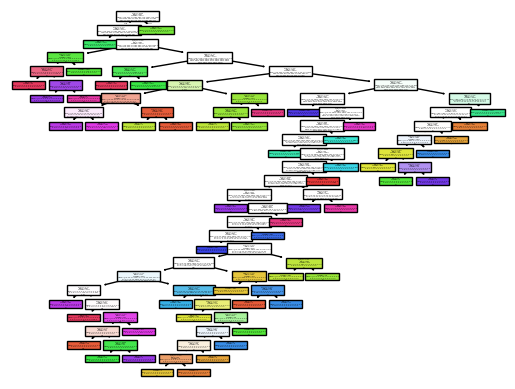

In [69]:
tree.plot_tree(model,filled = True)
plt.show()

In [70]:
def objective(trial):
    
    d1 = trial.suggest_int("d1",10,22)
    max_sample = trial.suggest_categorical("max_sample",[0.7, 0.8, 0.9])
    n = trial.suggest_int("n",6,20)
    
    model = RandomForestClassifier(n_estimators= n, max_depth = d1,  max_samples = max_sample)
    
    values = cross_validate(estimator = model, X = x_train, y=y_train, scoring="accuracy", cv=4,return_train_score=True,n_jobs=-1)
    
    train_ac = values["train_score"].mean()
    test_ac = values["test_score"].mean()
    trial.set_user_attr("train_ac",train_ac)
    return test_ac

In [71]:
space = {
    "d1": list(range(10,22)),
    "max_sample": [0.7, 0.8, 0.9],
    "n": list(range(6,20))
}
study = optuna.create_study(direction="maximize",sampler=GridSampler(search_space=space))
study.optimize(objective)

[I 2025-07-25 22:31:24,496] A new study created in memory with name: no-name-6f36ccd2-da9a-4cba-837e-b042e8a01561
[I 2025-07-25 22:31:33,995] Trial 0 finished with value: 1.0 and parameters: {'d1': 12, 'max_sample': 0.7, 'n': 12}. Best is trial 0 with value: 1.0.
[I 2025-07-25 22:31:43,869] Trial 1 finished with value: 0.9999702380952381 and parameters: {'d1': 12, 'max_sample': 0.7, 'n': 19}. Best is trial 0 with value: 1.0.
[I 2025-07-25 22:31:48,748] Trial 2 finished with value: 0.9999702380952381 and parameters: {'d1': 21, 'max_sample': 0.8, 'n': 6}. Best is trial 0 with value: 1.0.
[I 2025-07-25 22:31:54,121] Trial 3 finished with value: 1.0 and parameters: {'d1': 18, 'max_sample': 0.7, 'n': 10}. Best is trial 0 with value: 1.0.
[I 2025-07-25 22:31:59,464] Trial 4 finished with value: 1.0 and parameters: {'d1': 19, 'max_sample': 0.8, 'n': 9}. Best is trial 0 with value: 1.0.
[I 2025-07-25 22:32:04,326] Trial 5 finished with value: 0.9998511904761905 and parameters: {'d1': 10, 'max_

In [42]:
study.best_value

1.0

In [43]:
study.best_params

{'d1': 6, 'max_sample': 0.8, 'n': 19}

In [72]:
study.best_value

1.0

In [73]:
study.best_params

{'d1': 12, 'max_sample': 0.7, 'n': 12}

In [77]:
x_train, x_test, y_train, y_test = train_test_split(fv, cv, test_size=0.2, stratify=cv)

In [46]:
rfc = RandomForestClassifier(n_estimators=12,max_depth=12,max_samples=0.7)
model = rfc.fit(x_train,y_train)
y_cv = model.predict(x_test)
accuracy_score(y_test,y_cv)

1.0

In [70]:
model

RandomForestClassifier(max_depth=12, max_samples=0.7, n_estimators=12)

In [47]:
import pickle

In [71]:
with open("sample_randomforest_hands_3.pkl", "wb") as f:
    pickle.dump(model, f)

In [12]:
import os
import cv2
import time
import pickle
import pandas as pd
import numpy as np
import mediapipe as mp
from gtts import gTTS

hd = mp.solutions.hands
model1 = hd.Hands(
    static_image_mode=False,
    max_num_hands=1,
    model_complexity=1,
    min_detection_confidence=0.8,
    min_tracking_confidence=0.8
)

with open("sample_randomforest_hands_3.pkl", "rb") as f:
    rfc= pickle.load(f)

vid = cv2.VideoCapture(3)

st = ''
last_pre = ""
last_prediction_time = 0
prediction_delay = 3
d = 0
while True:
    s, f = vid.read()
    
    if not s:
        break
        
    f = cv2.flip(f,1)
    rgb = f[:, :, ::-1] 
    result = model1.process(rgb)
    cv2.putText(f, f"Last Predicted: {last_pre}", (5,450 ), cv2.FONT_HERSHEY_COMPLEX, 1, (255, 255, 0), 2)
    if result.multi_hand_landmarks:
        row = []
        for i in result.multi_hand_landmarks:
            mp.solutions.drawing_utils.draw_landmarks(f, i, hd.HAND_CONNECTIONS)
            for j in i.landmark:
                row.extend([j.x, j.y, j.z])
        if len(row) == 63:
            pre1 = []
            md = np.array(row).reshape(21,3)
            center = md - md[0]
            distance = np.linalg.norm(md[0]-md[12])
            fpd = center/(distance+1e-6)
            pre1.append(fpd.flatten())
            current_time = time.time()
            if current_time - last_prediction_time >= prediction_delay:
                pre = rfc.predict(pre1)[0]
                last_pre = pre
                if pre == "Start":
                    d +=1
                if d == 1: 
                    if pre == "backspace":
                        st = st[:-1]
                    elif pre != "Start":
                        st = st + pre
                elif d == 2:
                    break

                last_prediction_time = current_time 
                cv2.putText(f, f"Predicted Char: {pre}", (5, 150), cv2.FONT_HERSHEY_COMPLEX, 1, (0, 0, 255), 2)

    if d == 1:
        cv2.putText(f, f"Typed Text: {st}", (5, 120), cv2.FONT_HERSHEY_COMPLEX, 1, (0, 255, 0), 2)
        
    elif d==0:
        cv2.putText(f, "You need to Start the prediction", (5, 120), cv2.FONT_HERSHEY_COMPLEX, 1, (0, 255, 0), 2)
    cv2.imshow("Koushik", f)

    if cv2.waitKey(1) & 0xFF == 27: 
        break

vid.release()
cv2.destroyAllWindows()
print(st)

tts = gTTS(text=st, lang='en')
tts.save("output.mp3")
os.system("start output.mp3")

WELCOME FRIENDS I AM KOUSHIK


0

In [ ]:
KOUSHIK RAJ

In [ ]:
ABCDEFGHIJKLMNOPQRSTUVWXYZ

In [3]:
from gtts import gTTS
import os

text = "Hello Koushik Raj, this is Google Text to Speech."
tts = gTTS(text=text, lang='en')

# Save to a file
tts.save("output.mp3")

# Play the file (platform-dependent)
os.system("start output.mp3")  # Windows
# os.system("afplay output.mp3")  # macOS
# os.system("mpg321 output.mp3")  # Linux


0

In [2]:
pip install gTTS

Note: you may need to restart the kernel to use updated packages.


In [6]:
import pyttsx3

engine = pyttsx3.init()

text = "Hello Koushik Raj, this is a text to speech conversion example in Python."

engine.say(text)
engine.runAndWait()
# Rate (speed)
engine.setProperty('rate', 150)

# Volume (0.0 to 1.0)
engine.setProperty('volume', 1.0)

# Change voice
voices = engine.getProperty('voices')
engine.setProperty('voice', voices[0].id)  # 0 = male, 1 = female (depends on system)
